<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [2]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [4]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [ ]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [ ]:
boston_df = pd.read_csv(boston_url)

In [10]:
boston_df

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [12]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [16]:
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

In [17]:
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [18]:
boston_df.duplicated().sum()

0

In [22]:
corr_matrix = boston_df.corr() #method='spearman'
print(corr_matrix.round(2))

            Unnamed: 0  CRIM    ZN  INDUS  CHAS   NOX    RM   AGE   DIS   RAD  \
Unnamed: 0        1.00  0.41 -0.10   0.40 -0.00  0.40 -0.08  0.20 -0.30  0.69   
CRIM              0.41  1.00 -0.20   0.41 -0.06  0.42 -0.22  0.35 -0.38  0.63   
ZN               -0.10 -0.20  1.00  -0.53 -0.04 -0.52  0.31 -0.57  0.66 -0.31   
INDUS             0.40  0.41 -0.53   1.00  0.06  0.76 -0.39  0.64 -0.71  0.60   
CHAS             -0.00 -0.06 -0.04   0.06  1.00  0.09  0.09  0.09 -0.10 -0.01   
NOX               0.40  0.42 -0.52   0.76  0.09  1.00 -0.30  0.73 -0.77  0.61   
RM               -0.08 -0.22  0.31  -0.39  0.09 -0.30  1.00 -0.24  0.21 -0.21   
AGE               0.20  0.35 -0.57   0.64  0.09  0.73 -0.24  1.00 -0.75  0.46   
DIS              -0.30 -0.38  0.66  -0.71 -0.10 -0.77  0.21 -0.75  1.00 -0.49   
RAD               0.69  0.63 -0.31   0.60 -0.01  0.61 -0.21  0.46 -0.49  1.00   
TAX               0.67  0.58 -0.31   0.72 -0.04  0.67 -0.29  0.51 -0.53  0.91   
PTRATIO           0.29  0.29

In [23]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


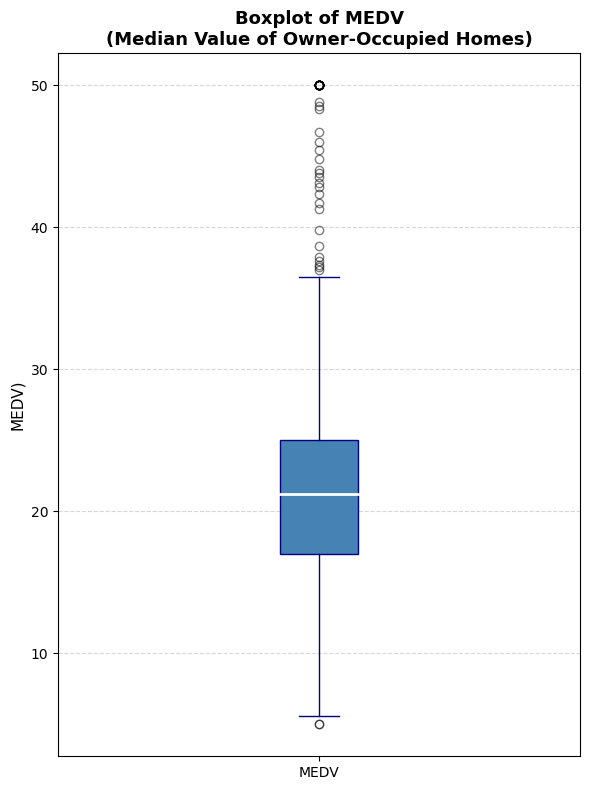

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 8))

ax.boxplot(boston_df['MEDV'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='white', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'),
           flierprops=dict(marker='o', color='steelblue', alpha=0.5))

ax.set_title('Boxplot of MEDV\n(Median Value of Owner-Occupied Homes)', fontsize=13, fontweight='bold')
ax.set_ylabel('MEDV)', fontsize=11)
ax.set_xticks([1])
ax.set_xticklabels(['MEDV'])
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

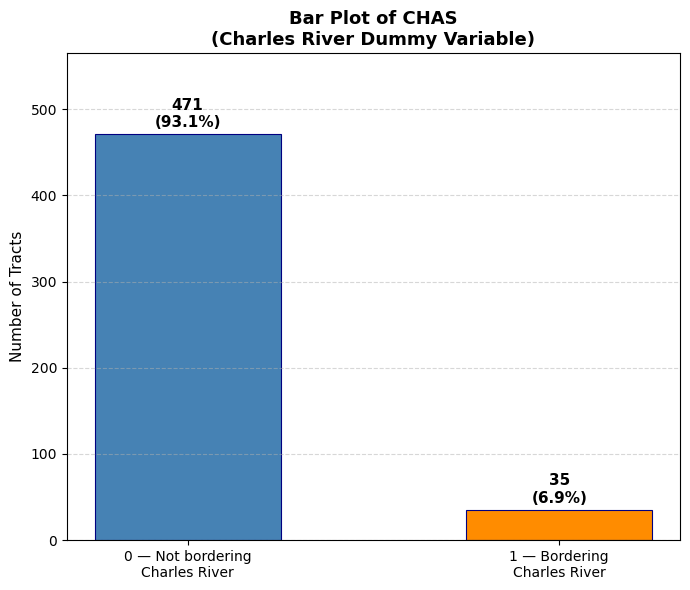

In [27]:
import matplotlib.pyplot as plt

chas_counts = boston_df['CHAS'].value_counts().sort_index()
labels = ['0 — Not bordering\nCharles River', '1 — Bordering\nCharles River']

fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.bar(labels, chas_counts.values, color=['steelblue', 'darkorange'],
              edgecolor='navy', linewidth=0.8, width=0.5)

# Annotate bars with counts and percentages
total = chas_counts.sum()
for bar, count in zip(bars, chas_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Bar Plot of CHAS\n(Charles River Dummy Variable)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Tracts', fontsize=11)
ax.set_ylim(0, max(chas_counts.values) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

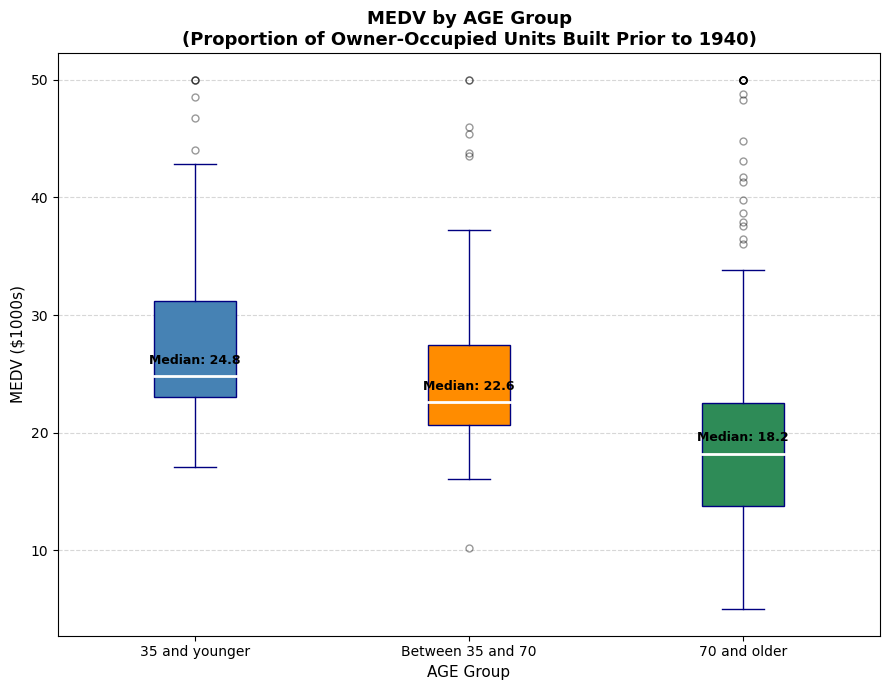

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Discretize AGE into three groups
boston_df['AGE_group'] = pd.cut(
    boston_df['AGE'],
    bins=[0, 35, 70, 100],
    labels=['35 and younger', 'Between 35 and 70', '70 and older']
)

# Group data for boxplot
groups = ['35 and younger', 'Between 35 and 70', '70 and older']
data = [boston_df[boston_df['AGE_group'] == g]['MEDV'].values for g in groups]

fig, ax = plt.subplots(figsize=(9, 7))

bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'),
                flierprops=dict(marker='o', alpha=0.4, markersize=5))

colors = ['steelblue', 'darkorange', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('navy')

# Annotate with median values
for i, (d, color) in enumerate(zip(data, colors), 1):
    median = pd.Series(d).median()
    ax.text(i, median + 0.8, f'Median: {median:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

ax.set_title('MEDV by AGE Group\n(Proportion of Owner-Occupied Units Built Prior to 1940)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('MEDV ($1000s)', fontsize=11)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(groups, fontsize=10)
ax.set_xlabel('AGE Group', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

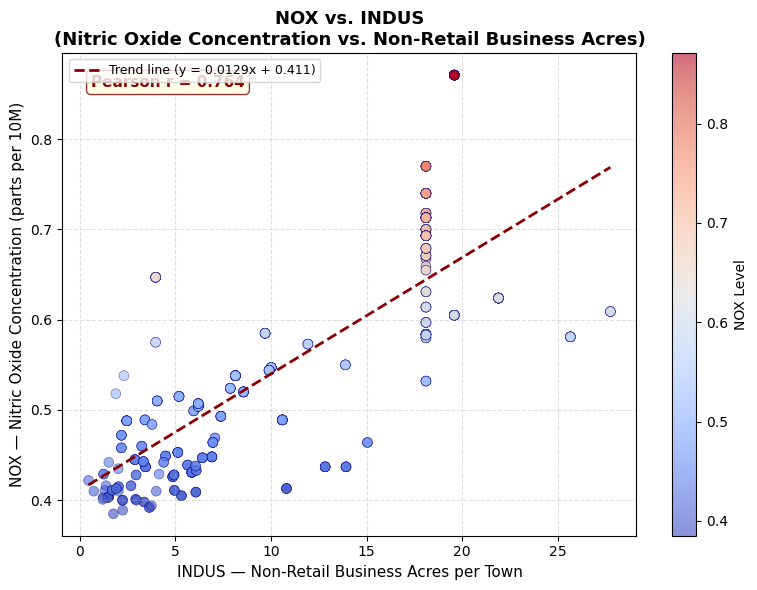

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    boston_df['INDUS'], boston_df['NOX'],
    alpha=0.6, edgecolors='navy', linewidths=0.4,
    c=boston_df['NOX'], cmap='coolwarm', s=50
)

# Add a regression trend line
m, b = np.polyfit(boston_df['INDUS'], boston_df['NOX'], 1)
x_line = np.linspace(boston_df['INDUS'].min(), boston_df['INDUS'].max(), 200)
ax.plot(x_line, m * x_line + b, color='darkred', linewidth=2, linestyle='--', label=f'Trend line (y = {m:.4f}x + {b:.3f})')

# Correlation annotation
corr = boston_df['INDUS'].corr(boston_df['NOX'])
ax.text(0.05, 0.93, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='darkred', alpha=0.8))

plt.colorbar(scatter, ax=ax, label='NOX Level')
ax.set_xlabel('INDUS — Non-Retail Business Acres per Town', fontsize=11)
ax.set_ylabel('NOX — Nitric Oxide Concentration (parts per 10M)', fontsize=11)
ax.set_title('NOX vs. INDUS\n(Nitric Oxide Concentration vs. Non-Retail Business Acres)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

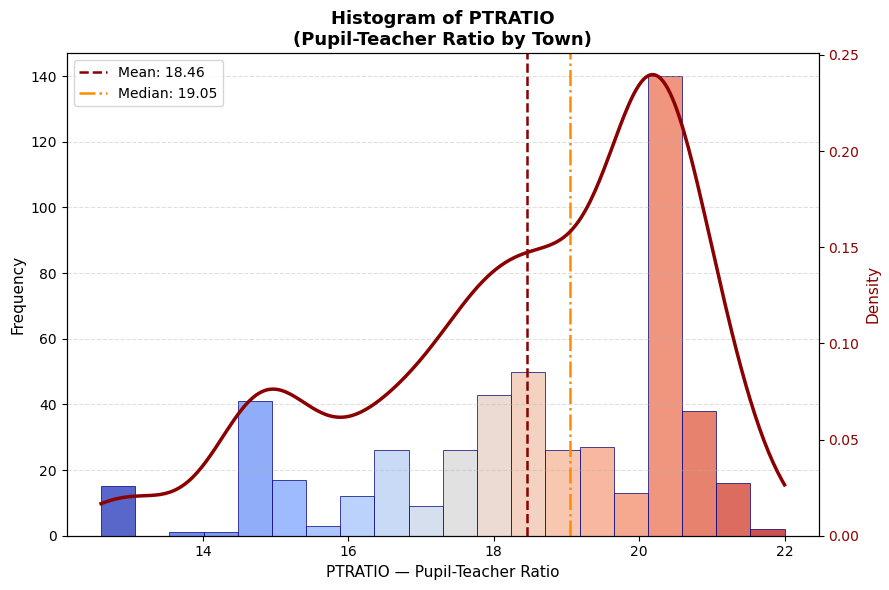

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(9, 6))

n, bins, patches = ax.hist(
    boston_df['PTRATIO'], bins=20,
    color='steelblue', edgecolor='navy', linewidth=0.6, alpha=0.85
)

# Color bars by value (low = green, high = red)
norm = plt.Normalize(bins.min(), bins.max())
cmap = plt.cm.coolwarm
for bin_val, patch in zip(bins, patches):
    patch.set_facecolor(cmap(norm(bin_val)))

# Overlay KDE curve
kde_x = np.linspace(boston_df['PTRATIO'].min(), boston_df['PTRATIO'].max(), 300)
kde = stats.gaussian_kde(boston_df['PTRATIO'])
ax2 = ax.twinx()
ax2.plot(kde_x, kde(kde_x), color='darkred', linewidth=2.5, label='KDE')
ax2.set_ylabel('Density', fontsize=11, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.set_ylim(0)

# Vertical lines for mean and median
mean_val = boston_df['PTRATIO'].mean()
median_val = boston_df['PTRATIO'].median()
ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=1.8, label=f'Mean: {mean_val:.2f}')
ax.axvline(median_val, color='darkorange', linestyle='-.', linewidth=1.8, label=f'Median: {median_val:.2f}')

ax.set_xlabel('PTRATIO — Pupil-Teacher Ratio', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Histogram of PTRATIO\n(Pupil-Teacher Ratio by Town)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [31]:
from scipy import stats

# Split MEDV into two groups based on CHAS
medv_chas0 = boston_df[boston_df['CHAS'] == 0]['MEDV']
medv_chas1 = boston_df[boston_df['CHAS'] == 1]['MEDV']

# Descriptive variance summary
print("=== Variance Summary ===")
print(f"CHAS = 0 | n = {len(medv_chas0):>3} | Var = {medv_chas1.var():.4f} | Std = {medv_chas0.std():.4f}")
print(f"CHAS = 1 | n = {len(medv_chas1):>3} | Var = {medv_chas1.var():.4f} | Std = {medv_chas1.std():.4f}")

# Levene's test
levene_stat, levene_p = stats.levene(medv_chas0, medv_chas1, center='mean')

print("\n=== Levene's Test Results ===")
print(f"Test Statistic (W): {levene_stat:.4f}")
print(f"p-value:            {levene_p:.4f}")

alpha = 0.05
if levene_p < alpha:
    print(f"\nResult: p = {levene_p:.4f} < α = {alpha} → Reject H₀")
    print("Conclusion: Variances are NOT equal (heteroscedastic)")
else:
    print(f"\nResult: p = {levene_p:.4f} ≥ α = {alpha} → Fail to reject H₀")
    print("Conclusion: Variances ARE equal (homoscedastic)")

=== Variance Summary ===
CHAS = 0 | n = 471 | Var = 139.6331 | Std = 8.8314
CHAS = 1 | n =  35 | Var = 139.6331 | Std = 11.8166

=== Levene's Test Results ===
Test Statistic (W): 8.7519
p-value:            0.0032

Result: p = 0.0032 < α = 0.05 → Reject H₀
Conclusion: Variances are NOT equal (heteroscedastic)


In [32]:
from scipy import stats

# Split MEDV by CHAS groups
medv_chas0 = boston_df[boston_df['CHAS'] == 0]['MEDV']
medv_chas1 = boston_df[boston_df['CHAS'] == 1]['MEDV']

# Descriptive summary
print("=== Group Summary ===")
print(f"CHAS = 0 (Not bounded) | n = {len(medv_chas0)} | Mean = {medv_chas0.mean():.2f} | Std = {medv_chas0.std():.2f}")
print(f"CHAS = 1 (Bounded)     | n = {len(medv_chas1)} | Mean = {medv_chas1.mean():.2f} | Std = {medv_chas1.std():.2f}")

t_stat, p_value = stats.ttest_ind(medv_chas0, medv_chas1, equal_var=False)

print("\n=== Welch's Independent T-Test Results ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p = {p_value:.4f} < α = {alpha} → Reject H₀")
    print("Conclusion: There IS a significant difference in MEDV between")
    print("            homes bounded and not bounded by the Charles River.")
else:
    print(f"\nResult: p = {p_value:.4f} ≥ α = {alpha} → Fail to reject H₀")
    print("Conclusion: There is NO significant difference in MEDV between the two groups.")

=== Group Summary ===
CHAS = 0 (Not bounded) | n = 471 | Mean = 22.09 | Std = 8.83
CHAS = 1 (Bounded)     | n = 35 | Mean = 28.44 | Std = 11.82

=== Welch's Independent T-Test Results ===
T-statistic: -3.1133
p-value:     0.0036

Result: p = 0.0036 < α = 0.05 → Reject H₀
Conclusion: There IS a significant difference in MEDV between
            homes bounded and not bounded by the Charles River.


In [33]:
from scipy import stats

if 'AGE_group' not in boston_df.columns:
    import pandas as pd
    boston_df['AGE_group'] = pd.cut(
        boston_df['AGE'],
        bins=[0, 35, 70, 100],
        labels=['35 and younger', 'Between 35 and 70', '70 and older']
    )

# Extract MEDV for each group
g1 = boston_df[boston_df['AGE_group'] == '35 and younger']['MEDV']
g2 = boston_df[boston_df['AGE_group'] == 'Between 35 and 70']['MEDV']
g3 = boston_df[boston_df['AGE_group'] == '70 and older']['MEDV']

# Descriptive summary per group
print("=== Group Summary ===")
for label, grp in [('35 and younger', g1), ('Between 35 and 70', g2), ('70 and older', g3)]:
    print(f"{label:<22} | n = {len(grp):>3} | Mean = {grp.mean():.2f} | Std = {grp.std():.2f}")

# One-way ANOVA
f_stat, p_value = stats.f_oneway(g1, g2, g3)

print("\n=== One-Way ANOVA Results ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p = {p_value:.4f} < α = {alpha} → Reject H₀")
    print("Conclusion: There IS a significant difference in MEDV across the AGE groups.")
else:
    print(f"\nResult: p = {p_value:.4f} ≥ α = {alpha} → Fail to reject H₀")
    print("Conclusion: There is NO significant difference in MEDV across the AGE groups.")

=== Group Summary ===
35 and younger         | n =  91 | Mean = 27.78 | Std = 7.64
Between 35 and 70      | n = 128 | Mean = 24.95 | Std = 6.97
70 and older           | n = 287 | Mean = 19.79 | Std = 9.52

=== One-Way ANOVA Results ===
F-statistic: 36.4076
p-value:     0.0000

Result: p = 0.0000 < α = 0.05 → Reject H₀
Conclusion: There IS a significant difference in MEDV across the AGE groups.


In [34]:
from scipy import stats
import numpy as np

# Pearson correlation test
corr_coef, p_value = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

# Confidence interval
n = len(boston_df)
z = np.arctanh(corr_coef)                       
se = 1 / np.sqrt(n - 3)                          
ci_low  = np.tanh(z - 1.96 * se)
ci_high = np.tanh(z + 1.96 * se)

print("=== Pearson Correlation Test: NOX vs. INDUS ===")
print(f"Sample size (n):        {n}")
print(f"Pearson r:              {corr_coef:.4f}")
print(f"95% Confidence Interval: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"p-value:                {p_value:.6f}")
print(f"R² (variance explained): {corr_coef**2 * 100:.2f}%")

alpha = 0.05
print("\n=== Interpretation ===")
if p_value < alpha:
    print(f"Result: p = {p_value:.6f} < α = {alpha} → Reject H₀")
    print("Conclusion: There IS a statistically significant linear correlation")
    print("            between NOX and INDUS.")
else:
    print(f"Result: p = {p_value:.6f} ≥ α = {alpha} → Fail to reject H₀")
    print("Conclusion: There is NO significant linear correlation between NOX and INDUS.")

=== Pearson Correlation Test: NOX vs. INDUS ===
Sample size (n):        506
Pearson r:              0.7637
95% Confidence Interval: [0.7247, 0.7977]
p-value:                0.000000
R² (variance explained): 58.32%

=== Interpretation ===
Result: p = 0.000000 < α = 0.05 → Reject H₀
Conclusion: There IS a statistically significant linear correlation
            between NOX and INDUS.


In [35]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Define predictor and response
X = boston_df['DIS']
y = boston_df['MEDV']

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Full regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.21e-08
Time:                        23:04:07   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0